# Simulation

We also embed the simulator into ScisTreeCNA, allowing users to experiment with the method under different scenarios.  
In the example below, we simulate **100 cells** and **100 sites** for illustration.

:::{tip}
Increasing `tree_batch_size` and `node_batch_size` can improve efficiency when working with larger numbers of cells.
:::


In [1]:
import numpy as np
import pandas as pd
import scistreecna as scna

In [ ]:
n_cells = 100
n_sites = 100
reads, tree, tg = scna.simulate.simulate_data(n_cells=n_cells, n_sites=100, mode="clt")
cell_names = [str(_) for _ in range(n_cells)]


scistreecna_tree, scistreecna_geno = scna.infer(
    reads,
    cn_min=1,
    cn_max=5,
    tree_batch_size=512,
    node_batch_size=1024,
    true_tree=tree,
    verbose=True,
    verbose_mode="all",
    cell_names=cell_names,
)
scistreecna_tree_acc = scna.util.tree_accuracy(tree, scistreecna_tree)
scistreecna_geno_acc = scna.util.genotype_accuarcy(tg, scistreecna_geno)
print("scistreecna geno", scistreecna_geno_acc)
print("scistreecna tree", scistreecna_tree_acc)

───────────────────────────────────────── ScisTreeCNA ──────────────────────────────────────────
                                     #Cell: 100 #Site: 100                                      
                   CN_MIN: 1 CN_MAX: 5 ADO: 0.1 SEQ_ERR: 0.01 CN_NOISE: 0.05                    
                    MAX_ITER: inf TREE_BATCH_SIZE: 512 NODE_BATCH_SIZE: 1024                    
───────────────────────────────────────── Local Search ─────────────────────────────────────────
[18:11:03] [Iteration 0]   Likelihood: -16546.0913 Tree accuracy: 0.2990   nRF: 0.7026          
           [Iteration 1]   Likelihood: -16531.8147 Tree accuracy: 0.3093   nRF: 0.6923          
           [Iteration 2]   Likelihood: -16521.0393 Tree accuracy: 0.3196   nRF: 0.6821          
[18:11:04] [Iteration 3]   Likelihood: -16510.6105 Tree accuracy: 0.3299   nRF: 0.6718          
           [Iteration 4]   Likelihood: -16500.8482 Tree accuracy: 0.3402   nRF: 0.6615          
           [Iteration 5]   Lik

Next, we compare our results with other methods. Running CellPhy in Colab is too slow; users who are interested can run it locally using the code provided above (it may run faster in a CPU-intensive environment). For a straightforward comparison, we evaluate only ScisTree2 and the copy-number NJ approach to demonstrate our performance.

:::{note}
In empirical results, CellPhy typically achieves slightly lower accuracy than ScisTree2, and DICE shows performance comparable to copy-number NJ.
:::

In [4]:
# check ScisTree2
scistree2tree, scistree2geno = scna.external.infer_scistree2_tree(reads, cell_names=cell_names)
scistree2_tree_accuracy = scna.util.tree_accuracy(tree, scistree2tree)
scistree2_geno_accuracy = scna.util.genotype_accuarcy(tg, scistree2geno)
print(f'ScisTree2 tree accuracy: {scistree2_tree_accuracy}, ScisTree2 genotype accuracy: {scistree2_geno_accuracy}')

# check copy-number neighbor joining
copy_number_tree = scna.external.infer_copy_number_tree(
    reads[:, :, 2], cell_names=cell_names
)
copy_number_tree_acc = scna.util.tree_accuracy(tree, copy_number_tree)
print("copy number nj tree", copy_number_tree_acc)

ScisTree2 tree accuracy: 0.28865979381443296, ScisTree2 genotype accuracy: 0.9932
copy number nj tree 0.4845360824742268


Last, we perform inference on simulated data with clonal structure (mode="clone"). We first generate a clonal tree, where cells within the same clone are closely related, and cells from different clones are far apart. We then average the copy numbers of cells within each clone to obtain clone-specific copy numbers and run ScisTreeCNA using these averaged values.

:::{tip}
Because we are using averaged copy numbers, we set a larger copy-number noise to prevent ScisTreeCNA from performing excessive optimization at single-cell level, which could introduce inaccurate fine-grained structures.
:::

In [7]:
n_cells = 60
n_sites = 100
n_clusters = 8
reads, tree, tg = scna.simulate.simulate_data(n_cells=n_cells, n_sites=n_sites, n_clusters=n_clusters, mode="clone")
cell_names = [str(_) for _ in range(n_cells)]


scistreecna_tree, scistreecna_geno = scna.infer(
    reads,
    cn_min=1,
    cn_max=5,
    tree_batch_size=256,
    node_batch_size=256,
    cn_noise=0.5, # we suggest a larger copy-number noise as averaging clonal copy number is not very accurate
    true_tree=tree,
    verbose=True,
    verbose_mode="all",
    cell_names=cell_names,
)
scistreecna_tree_acc = scna.util.tree_accuracy(tree, scistreecna_tree)
scistreecna_geno_acc = scna.util.genotype_accuarcy(tg, scistreecna_geno)
print("scistreecna geno", scistreecna_geno_acc)
print("scistreecna tree", scistreecna_tree_acc)

───────────────────────────────────────── ScisTreeCNA ──────────────────────────────────────────
                                      #Cell: 60 #Site: 100                                      
                    CN_MIN: 1 CN_MAX: 5 ADO: 0.1 SEQ_ERR: 0.01 CN_NOISE: 0.5                    
                    MAX_ITER: inf TREE_BATCH_SIZE: 256 NODE_BATCH_SIZE: 256                     
───────────────────────────────────────── Local Search ─────────────────────────────────────────
[18:31:41] [Iteration 0]   Likelihood: -15401.9719 Tree accuracy: 0.4561   nRF: 0.5478          
[18:31:42] [Iteration 1]   Likelihood: -15371.2336 Tree accuracy: 0.4737   nRF: 0.5304          
           [Iteration 2]   Likelihood: -15359.9711 Tree accuracy: 0.4737   nRF: 0.5304          
           [Iteration 3]   Likelihood: -15349.2442 Tree accuracy: 0.4737   nRF: 0.5304          
           [Iteration 4]   Likelihood: -15342.0854 Tree accuracy: 0.4912   nRF: 0.5130          
[18:31:43] [Iteration 5]   Lik

In [14]:
# check ScisTree2
scistree2tree, scistree2geno = scna.external.infer_scistree2_tree(reads, cell_names=cell_names)
scistree2_tree_accuracy = scna.util.tree_accuracy(tree, scistree2tree)
scistree2_geno_accuracy = scna.util.genotype_accuarcy(tg, scistree2geno)
print(f'ScisTree2 tree accuracy: {scistree2_tree_accuracy}, ScisTree2 genotype accuracy: {scistree2_geno_accuracy}')

# check copy-number neighbor joining
copy_number_tree = scna.external.infer_copy_number_tree(
    reads[:, :, 2], cell_names=cell_names
)
copy_number_tree_acc = scna.util.tree_accuracy(tree, copy_number_tree)
print("copy number nj tree", copy_number_tree_acc)

ScisTree2 tree accuracy: 0.45614035087719296, ScisTree2 genotype accuracy: 0.985
copy number nj tree 0.2631578947368421


We then visualize the inferred trees, with node labels colored according to their clone assignments.

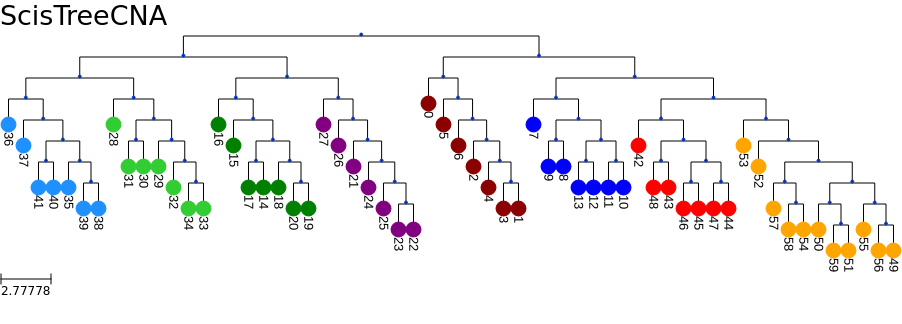

In [11]:
import os
os.environ['QT_QPA_PLATFORM']='offscreen'
from ete4 import Tree
from ete4.treeview import TreeStyle, NodeStyle, TextFace
def generate_color_list(n):
    COLOR_PALETTE = [
        "red", "#0000FF", "green", "#FFA500", "purple",  # Red, Blue, Green, Orange, Purple
        "darkred", "#1E90FF", "#32CD32", "#FFD700", "#FF69B4",  # Dark Red, Dodger Blue, Lime Green, Gold, Hot Pink
        "teal", "#800080", "maroon", "#00FFFF", "#FF4500",  # Teal, Violet, Maroon, Cyan, OrangeRed
        "navy", "#A52A2A", "lime", "#B8860B", "#DC143C", # Navy, Brown, Lime, DarkGoldenRod, Crimson
        "olive", "#008080", "fuchsia", "#4B0082", "sienna" # Olive, Teal, Fuchsia, Indigo, Sienna
    ]
    if n <= 0:
        return []
    color_list = []
    for i in range(n):
        color = COLOR_PALETTE[i % len(COLOR_PALETTE)]
        color_list.append(color)
    return color_list


cell2clone = {}
for leaf in tree.get_leaves():
  leaf = tree[leaf]
  cell2clone[leaf.name] = str(leaf.cid)



t = Tree(scistreecna_tree.output())
clusters = list(set(cell2clone.values()))
n_clusters = len(clusters)
colors = generate_color_list(n_clusters)
color_maps = {clusters[i]: colors[i] for i in range(n_clusters)}
ts = TreeStyle()

for leaf in t.traverse():
    if leaf.is_leaf:
        clone_name = cell2clone[leaf.name]
        color = color_maps[clone_name]
        nstyle = NodeStyle()
        nstyle['fgcolor'] = color
        nstyle['size'] = 15
        leaf.set_style(nstyle)
ts.show_leaf_name = True
ts.mode = "r"
ts.rotation = 90
ts.title.add_face(TextFace('ScisTreeCNA', fsize=20,), column=0)
t.render("%%inline", tree_style=ts)

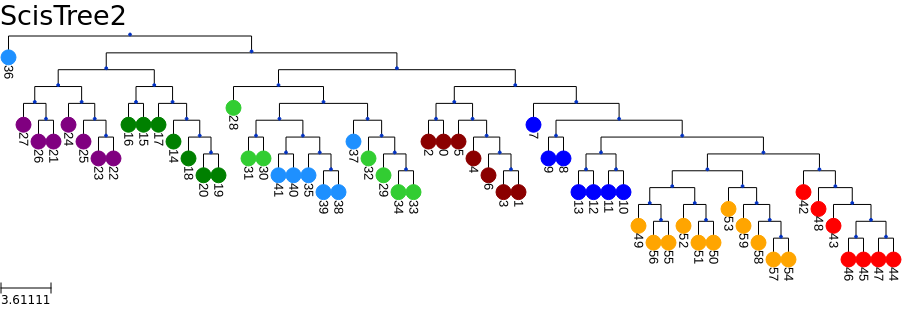

In [12]:
t = Tree(scistree2tree.output())
clusters = list(set(cell2clone.values()))
n_clusters = len(clusters)
colors = generate_color_list(n_clusters)
color_maps = {clusters[i]: colors[i] for i in range(n_clusters)}
ts = TreeStyle()
for leaf in t.traverse():
  if leaf.is_leaf:
    clone_name = cell2clone[leaf.name]
    color = color_maps[clone_name]
    nstyle = NodeStyle()
    nstyle['fgcolor'] = color
    nstyle['size'] = 15
    leaf.set_style(nstyle)
ts.show_leaf_name = True
ts.mode = "r"
ts.rotation = 90
ts.title.add_face(TextFace('ScisTree2', fsize=20,), column=0)
t.render("%%inline", tree_style=ts)



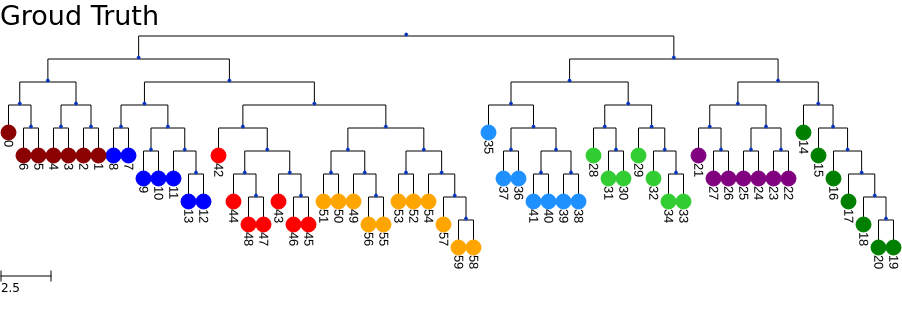

In [13]:
t = Tree(tree.output())
clusters = list(set(cell2clone.values()))
n_clusters = len(clusters)
colors = generate_color_list(n_clusters)
color_maps = {clusters[i]: colors[i] for i in range(n_clusters)}
ts = TreeStyle()
for leaf in t.traverse():
  if leaf.is_leaf:
    clone_name = cell2clone[leaf.name]
    color = color_maps[clone_name]
    nstyle = NodeStyle()
    nstyle['fgcolor'] = color
    nstyle['size'] = 15
    leaf.set_style(nstyle)
ts.show_leaf_name = True
ts.mode = "r"
ts.rotation = 90
ts.title.add_face(TextFace('Groud Truth', fsize=20,), column=0)
t.render("%%inline", tree_style=ts)